# Snow segmentation training

This notebook trains state-of-the-art semantic segmentation models on the curated Sentinel-2 snow dataset. It reuses the encoders/decoders and PyTorch Lightning model definitions from `2_train_state_of_the_art` while adding 5-fold cross-validation, manifest-driven dataloaders, and live visualizations of training progress.


In [1]:
import os
import random
from pathlib import Path
from typing import Iterable, Optional, Sequence, Tuple, Union

import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import rasterio
from rasterio.enums import Resampling
import torch
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode
from torch.optim import lr_scheduler

from my_code.model import MyModel

C:\Users\Domen\anaconda3\lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
pl.seed_everything(42, workers=True)
torch.set_float32_matmul_precision('medium')
torch.backends.cudnn.benchmark = True

Global seed set to 42


In [3]:
CONFIG = {
    "num_folds": 1,
    "max_epochs": 25,
    "batch_size": 8,
    "num_workers": 0, #2,
    "learning_rate": 6e-4,
    "weight_decay": 1e-2,
    "optimizer": "adamw",
    "scheduler": "polynomial",
    "loss_function": "CrossEntropyLoss",  # or "FocalLoss"
    "architecture": "Unet", #"Unet", "GASSL-basic"
    "image_size": 512,
    "mask_size": 1024,
    "rgb_indexes": (4, 3, 2),
    "use_all_bands": False,
    "band_mode": "all",  # set to "rgb" or "all" to override use_all_bands
    "train_from_scratch": False,
    "checkpoint_path": "D:\\analiza_snezisc2\\3_train_state_of_the_art\\trained_model\\all\\Unet\\CrossEntropyLoss\\checkpoints\\last.ckpt", #SET TO LOAD MODEL FROM FILE
    "augment": True,
    "stats_sample_limit": 64,
    "recompute_stats_per_fold": False,
    "log_every_n_steps": 20,
    "grad_clip": 1.0,
    "precision": "16",
    "monitor_metric": "train_mIOU",
}

NOTEBOOK_CWD = Path(os.getcwd()).resolve()
if (NOTEBOOK_CWD / "2_train_state_of_the_art").exists():
    TRAINING_ROOT = NOTEBOOK_CWD / "2_train_state_of_the_art"
else:
    TRAINING_ROOT = NOTEBOOK_CWD
RUNS_DIR = TRAINING_ROOT / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

BAND_MODE = CONFIG.get("band_mode")
if BAND_MODE is None:
    BAND_MODE = "all_spectral_bands" if CONFIG["use_all_bands"] else "rgb"

TRAINED_MODEL_DIR = TRAINING_ROOT / "trained_model" / BAND_MODE / CONFIG["architecture"] / CONFIG["loss_function"]
TRAINED_MODEL_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ROOT_CANDIDATES = [
    Path("1_download_data_and_create_dataset/dataset"),
    Path("../1_download_data_and_create_dataset/dataset"),
    Path("../../1_download_data_and_create_dataset/dataset"),
]

def find_dataset_root() -> Path:
    for candidate in DATASET_ROOT_CANDIDATES:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate dataset directory. Please update DATASET_ROOT_CANDIDATES.")

DATASET_ROOT = find_dataset_root()
MANIFEST_PATH = DATASET_ROOT / "manifest.csv"
manifest = pd.read_csv(MANIFEST_PATH)
print(f"Loaded {len(manifest)} tiles from {MANIFEST_PATH}")


Loaded 8299 tiles from D:\analiza_snezisc2\1_download_data_and_create_dataset\dataset\manifest.csv


In [4]:
MIN_RAW_VARIANCE = 1e-4

def resolve_path(relative_path: str) -> Path:
    normalized = relative_path.replace('\\', '/')
    return DATASET_ROOT / Path(normalized)


def _normalize_out_size(out_size: Union[int, Tuple[int, int], None]) -> Optional[Tuple[int, int]]:
    if out_size is None:
        return None
    if isinstance(out_size, int):
        return (out_size, out_size)
    return tuple(out_size)


def read_multispectral_image(
    path: Path,
    band_indexes: Sequence[int],
    out_size: Union[int, Tuple[int, int], None] = None,
) -> np.ndarray:
    with rasterio.open(path) as src:
        if not band_indexes:
            selected = list(range(1, src.count + 1))
        else:
            selected = [idx for idx in band_indexes if idx <= src.count]
            if not selected:
                selected = [1]
        target_size = _normalize_out_size(out_size)
        if target_size is not None:
            data = src.read(
                selected,
                out_shape=(len(selected), target_size[0], target_size[1]),
                resampling=Resampling.bilinear,
            ).astype(np.float32)
        else:
            data = src.read(selected).astype(np.float32)
    data = np.moveaxis(data, 0, -1)
    data = np.clip(data, 0, None)
    if not np.isfinite(data).all():
        raise ValueError(f"Non-finite values in {path}")
    if data.ptp() < MIN_RAW_VARIANCE:
        raise ValueError(f"Image {path} lacks contrast")
    max_val = data.max()
    if max_val > 0:
        data /= max_val
    return data


def read_mask(
    path: Path,
    out_size: Union[int, Tuple[int, int], None] = None,
) -> np.ndarray:
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.int64)
    target_size = _normalize_out_size(out_size)
    if target_size is not None and (data.shape[0] != target_size[0] or data.shape[1] != target_size[1]):
        data = cv2.resize(
            data,
            dsize=(target_size[1], target_size[0]),
            interpolation=cv2.INTER_NEAREST,
        )
    return data


def joint_random_flip(
    image: torch.Tensor, mask: torch.Tensor, p: float = 0.5
) -> Tuple[torch.Tensor, torch.Tensor]:
    if random.random() < p:
        image = TF.hflip(image)
        mask = torch.flip(mask, dims=[-1])
    if random.random() < p:
        image = TF.vflip(image)
        mask = torch.flip(mask, dims=[-2])
    return image, mask


class SnowSegmentationDataset(Dataset):
    def __init__(
        self,
        manifest_df: pd.DataFrame,
        indices: Sequence[int],
        band_indexes: Sequence[int],
        image_size: Optional[int],
        mask_size: Optional[int],
        augment: bool = False,
        resolve_path_fn=resolve_path,
    ):
        self.manifest_df = manifest_df.reset_index(drop=True)
        self.indices = list(indices)
        self.band_indexes = tuple(band_indexes)
        self.image_size = image_size
        self.mask_size = mask_size
        self.augment = augment
        self.resolve_path = resolve_path_fn

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        entry = self.manifest_df.iloc[self.indices[idx]]
        image = read_multispectral_image(
            self.resolve_path(entry['sentinel_path']),
            self.band_indexes,
            out_size=self.image_size,
        )
        mask = read_mask(
            self.resolve_path(entry['snow_mask_path']),
            out_size=self.mask_size,
        )
        image_tensor = torch.from_numpy(np.moveaxis(image, -1, 0)).float()
        mask_tensor = torch.from_numpy(mask).long()
        if self.augment:
            image_tensor, mask_tensor = joint_random_flip(image_tensor, mask_tensor)
        return image_tensor, mask_tensor


def compute_channel_stats(
    manifest_df: pd.DataFrame,
    indices: Sequence[int],
    band_indexes: Sequence[int],
    sample_limit: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    rng = random.Random(42)
    order = list(indices)
    rng.shuffle(order)
    if sample_limit is not None:
        order = order[:sample_limit]
    sums = None
    sums_sq = None
    total = 0
    for idx in order:
        entry = manifest_df.iloc[idx]
        img = read_multispectral_image(resolve_path(entry['sentinel_path']), band_indexes)
        pixels = img.reshape(-1, img.shape[-1])
        if sums is None:
            sums = np.zeros(pixels.shape[1], dtype=np.float64)
            sums_sq = np.zeros_like(sums)
        sums += pixels.sum(axis=0)
        sums_sq += np.square(pixels).sum(axis=0)
        total += pixels.shape[0]
    means = sums / total
    stds = np.sqrt(np.maximum(sums_sq / total - means ** 2, 1e-12))
    return means, stds


In [5]:
def determine_band_indexes() -> Tuple[int, ...]:
    sample_entry = manifest.iloc[0]
    with rasterio.open(resolve_path(sample_entry['sentinel_path'])) as src:
        use_all = CONFIG["use_all_bands"]
        if CONFIG.get("band_mode") == "all":
            use_all = True
        elif CONFIG.get("band_mode") == "rgb":
            use_all = False
        if use_all:
            return tuple(range(1, src.count + 1))
        selected = [idx for idx in CONFIG["rgb_indexes"] if idx <= src.count]
        if not selected:
            selected = [1]
        return tuple(selected)

SELECTED_BANDS = determine_band_indexes()
print(f"Using bands: {SELECTED_BANDS} (total {len(SELECTED_BANDS)})")

Using bands: (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13) (total 13)


In [6]:
class SnowSegLightningModule(MyModel):
    def __init__(
        self,
        arch: str,
        in_channels: int,
        train_means,
        train_stds,
        loss_function: str,
        optimizer_name: str,
        learning_rate: float,
        weight_decay: float,
        scheduler_name: str,
        n_iters_training: int
    ):
        super().__init__(
            arch,
            in_channels,
            out_classes=2,
            train_channel_means=train_means,
            train_channel_stds=train_stds,
            loss_function=loss_function,
            n_iters_training=n_iters_training,
        )
        self.optimizer_name = optimizer_name.lower()
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.scheduler_name = scheduler_name.lower()

    def configure_optimizers(self):
        if self.optimizer_name == "adam":
            optimizer = torch.optim.Adam(
                self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay
            )
        elif self.optimizer_name == "sgd":
            optimizer = torch.optim.SGD(
                self.parameters(), lr=self.learning_rate, momentum=0.9, weight_decay=self.weight_decay
            )
        else:
            optimizer = torch.optim.AdamW(
                self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay
            )
        if self.scheduler_name == "polynomial":
            scheduler = lr_scheduler.PolynomialLR(
                optimizer, total_iters=max(1, int(self.n_iters_training))
            )
            return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "interval": "step"}}
        elif self.scheduler_name == "cosine":
            scheduler = lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=max(1, int(self.n_iters_training))
            )
            return {"optimizer": optimizer, "lr_scheduler": scheduler}
        return optimizer

class PredictionPreviewCallback(pl.callbacks.Callback):
    def __init__(self, fold_dir: Path, dataset: Dataset, num_examples: int = 3):
        self.fold_dir = Path(fold_dir)
        self.dataset = dataset
        self.num_examples = num_examples
        self.output_dir = self.fold_dir / "previews"
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def on_validation_epoch_end(self, trainer, pl_module):
        if len(self.dataset) == 0:
            return
        pl_module.eval()
        device = pl_module.device
        rng = np.random.default_rng(seed=trainer.current_epoch)
        sample_count = min(self.num_examples, len(self.dataset))
        indices = rng.choice(len(self.dataset), size=sample_count, replace=False)
        for idx in indices:
            image_tensor, mask_tensor = self.dataset[idx]
            image_np = image_tensor.cpu().numpy()
            input_batch = image_tensor.unsqueeze(0).to(device)
            with torch.no_grad():
                logits = pl_module(input_batch)
            pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()
            target_mask = mask_tensor.cpu().numpy()

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            show_image = image_np[:3] if image_np.shape[0] >= 3 else image_np
            axes[0].imshow(np.moveaxis(show_image, 0, -1))
            axes[0].set_title("Input")
            axes[1].imshow(target_mask, cmap='gray')
            axes[1].set_title("Target")
            axes[2].imshow(pred_mask, cmap='gray')
            axes[2].set_title("Prediction")
            for ax in axes:
                ax.axis('off')
            outfile = self.output_dir / f"epoch_{trainer.current_epoch:03d}_sample_{idx}.png"
            fig.tight_layout()
            fig.savefig(outfile)
            plt.close(fig)
class ProgressFileLogger(pl.callbacks.Callback):
    def __init__(self, log_path: Path):
        self.log_path = Path(log_path)
        self.log_path.parent.mkdir(parents=True, exist_ok=True)
        self.log_path.write_text("")

    def _write_line(self, text: str) -> None:
        with self.log_path.open("a", encoding="utf-8") as f:
            f.write(text + "\n")

    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx) -> None:
        num_batches = trainer.num_training_batches or 1
        current = trainer.fit_loop.epoch_loop._batches_that_stepped
        percent = 100.0 * current / num_batches
        metrics = {}
        progress_cb = getattr(trainer, "progress_bar_callback", None)
        if progress_cb and hasattr(progress_cb, "get_metrics"):
            metrics = progress_cb.get_metrics(trainer, pl_module)
        elif trainer.progress_bar_dict:
            metrics = trainer.progress_bar_dict
        metric_str = ", ".join(f"{k}={v}" for k, v in metrics.items())
        line = f"Epoch {trainer.current_epoch}: {percent:.1f}% | batch {current}/{num_batches} | {metric_str}"
        self._write_line(line)

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        metric_str = ", ".join(f"{k}={v:.4f}" for k, v in metrics.items())
        self._write_line(f"Validation epoch {trainer.current_epoch}: {metric_str}")


class TrainHistoryCallback(pl.callbacks.Callback):
    def __init__(self):
        self.history = []

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        record = {"epoch": int(trainer.current_epoch)}
        for key in ["train_loss", "train_mIOU"]:
            value = metrics.get(key)
            if value is not None:
                record[key] = float(value.detach().cpu())
        self.history.append(record)


In [7]:
all_indices = list(range(len(manifest)))

means, stds = compute_channel_stats(
    manifest, all_indices, SELECTED_BANDS, sample_limit=CONFIG["stats_sample_limit"]
)

stats_payload = {
    "rgb_indexes": list(SELECTED_BANDS),
    "sample_limit": CONFIG["stats_sample_limit"],
    "means": np.asarray(means).tolist(),
    "stds": np.asarray(stds).tolist(),
}
(TRAINED_MODEL_DIR / "channel_stats.json").write_text(json.dumps(stats_payload, indent=2))
print(f"Saved channel statistics to {TRAINED_MODEL_DIR / 'channel_stats.json'}")

train_dataset = SnowSegmentationDataset(
    manifest, all_indices, SELECTED_BANDS, CONFIG["image_size"], CONFIG["mask_size"], augment=CONFIG["augment"]
)
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    persistent_workers=CONFIG["num_workers"] > 0,
    drop_last=True,
)

n_iters = max(1, len(train_loader) * CONFIG["max_epochs"])
if CONFIG.get("train_from_scratch", True):
    model = SnowSegLightningModule(
        arch=CONFIG["architecture"],
        in_channels=len(SELECTED_BANDS),
        train_means=means,
        train_stds=stds,
        loss_function=CONFIG["loss_function"],
        optimizer_name=CONFIG["optimizer"],
        learning_rate=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
        scheduler_name=CONFIG["scheduler"],
        n_iters_training=n_iters,
    )

    log_path = TRAINED_MODEL_DIR / "training.log"
    checkpoint_cb = pl.callbacks.ModelCheckpoint(
        dirpath=str(TRAINED_MODEL_DIR / "checkpoints"),
        filename="snow-best",
        monitor=CONFIG["monitor_metric"],
        mode="max",
        save_top_k=1,
        save_last=True,
    )
    history_cb = TrainHistoryCallback()
    progress_logger = ProgressFileLogger(log_path)

    trainer = pl.Trainer(
        logger=pl.loggers.CSVLogger(save_dir=str(TRAINED_MODEL_DIR), name="lightning"),
        max_epochs=CONFIG["max_epochs"],
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        precision=CONFIG["precision"] if torch.cuda.is_available() else 32,
        gradient_clip_val=CONFIG["grad_clip"],
        default_root_dir=str(TRAINED_MODEL_DIR),
        log_every_n_steps=CONFIG["log_every_n_steps"],
        callbacks=[history_cb, checkpoint_cb, progress_logger],
        enable_progress_bar=True,
        num_sanity_val_steps=0,
    )

    trainer.fit(model, train_dataloaders=train_loader)
    trainer.save_checkpoint(str(TRAINED_MODEL_DIR / "model.ckpt"))

    history_df = pd.DataFrame(history_cb.history)
else:
    ckpt_path = Path(CONFIG.get("checkpoint_path", ""))
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")
    model = SnowSegLightningModule.load_from_checkpoint(
        str(ckpt_path),
        arch=CONFIG["architecture"],
        in_channels=len(SELECTED_BANDS),
        train_means=means,
        train_stds=stds,
        loss_function=CONFIG["loss_function"],
        optimizer_name=CONFIG["optimizer"],
        learning_rate=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
        scheduler_name=CONFIG["scheduler"],
        n_iters_training=n_iters,
    )
    history_df = pd.DataFrame()


Saved channel statistics to D:\analiza_snezisc2\3_train_state_of_the_art\trained_model\all\Unet\CrossEntropyLoss\channel_stats.json


In [8]:
if history_df.empty:
    print("No history captured yet.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    axes[0].plot(history_df["epoch"], history_df.get("train_loss", np.nan), label="train")
    axes[1].plot(history_df["epoch"], history_df.get("train_mIOU", np.nan), label="train")
    axes[0].set_title("Loss per epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[1].set_title("mIoU per epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("mIoU")
    for ax in axes:
        ax.grid(True, linestyle=":")
        ax.legend()
    plt.tight_layout()
    history_path = TRAINED_MODEL_DIR / "history.png"
    plt.savefig(history_path, dpi=300)
    print(f"Saved history plot to {history_path}")


No history captured yet.


Loaded 8 test tiles from D:\analiza_snezisc2\2_download_test_data_and_create_test_dataset\test_dataset\manifest.csv
Working on probability: 0.01


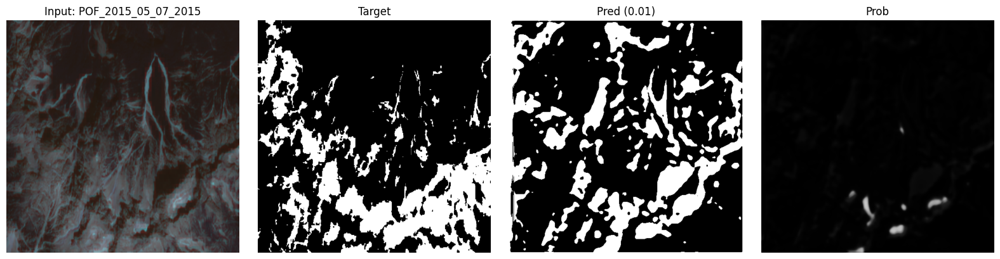

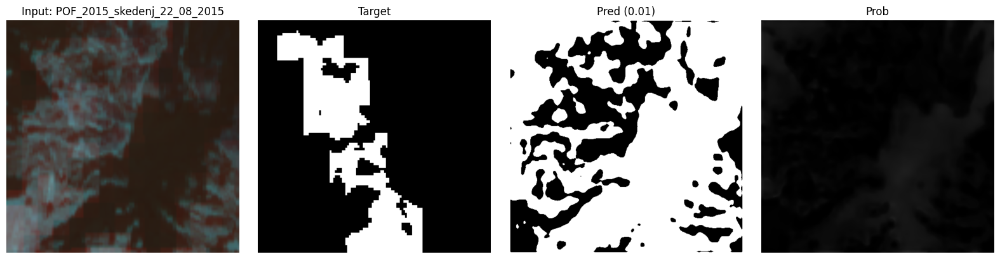

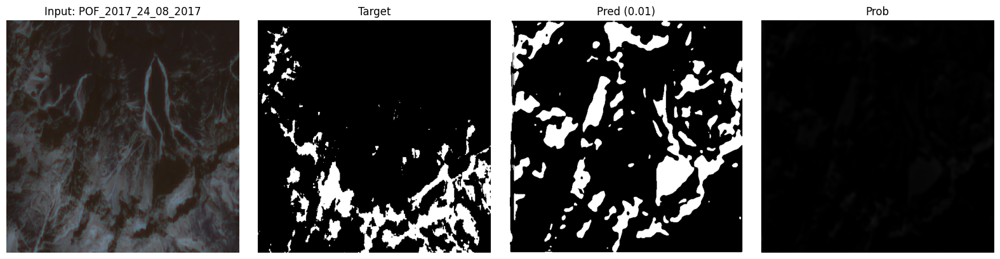

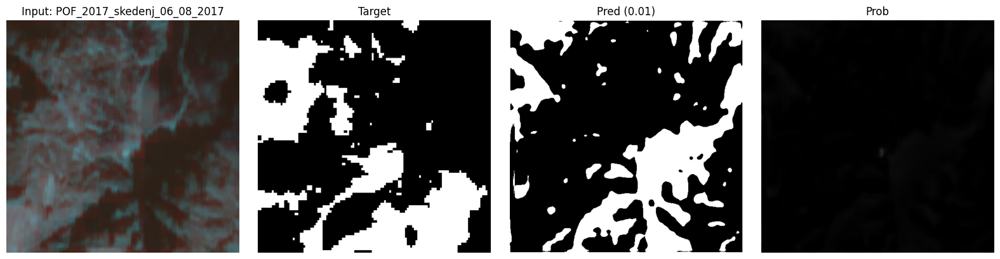

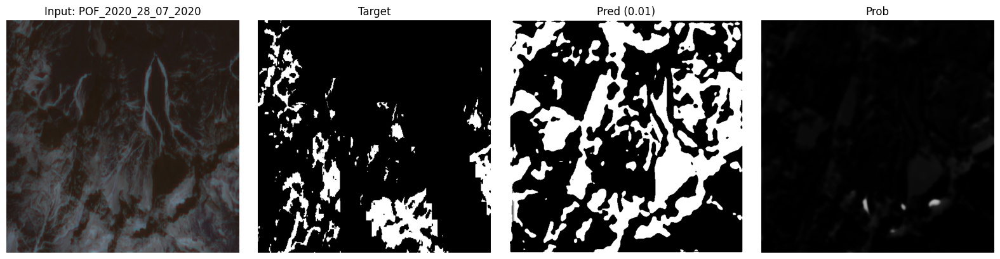

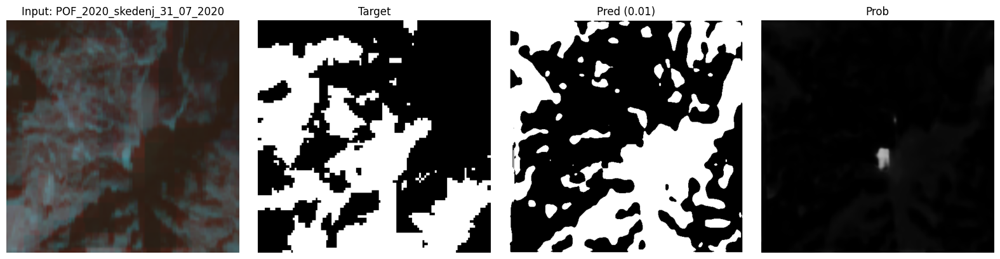

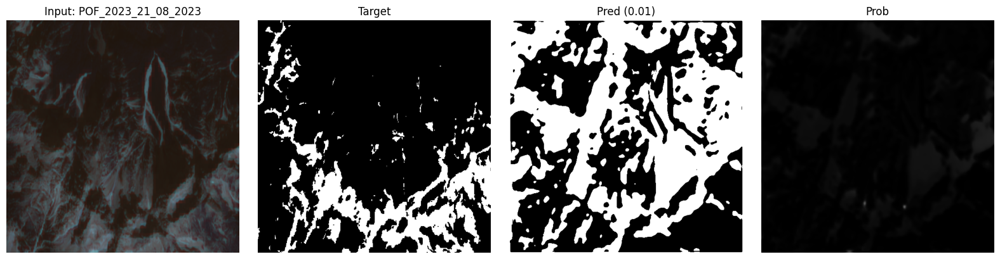

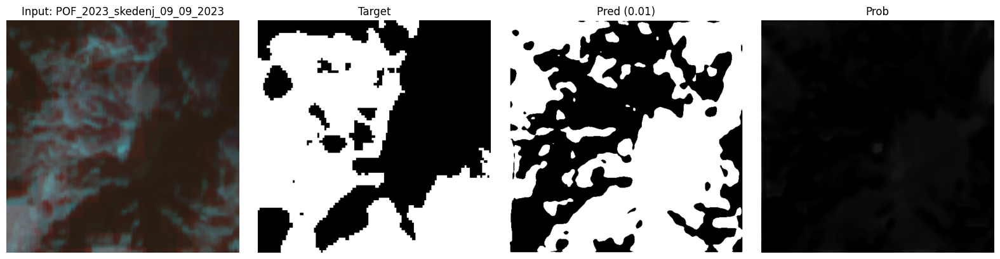

target IoU: class0=0.4759, class1=0.1853, mIoU=0.3306
target F1 : class0=0.6449, class1=0.3127, mF1 =0.4788
handGT IoU: class0=0.5933, class1=0.0368, mIoU=0.3150
handGT F1 : class0=0.7447, class1=0.0709, mF1 =0.4078
Saved predictions to D:\analiza_snezisc2\3_train_state_of_the_art\trained_model\all\Unet\CrossEntropyLoss\predictions
Working on probability: 0.1


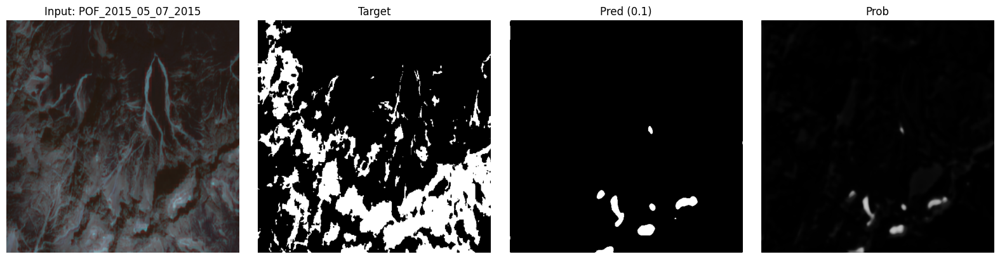

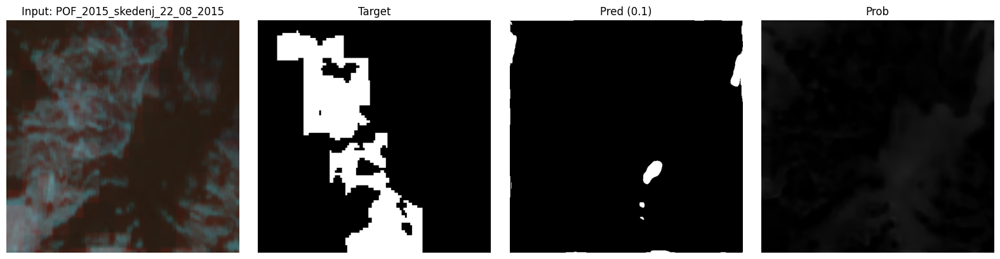

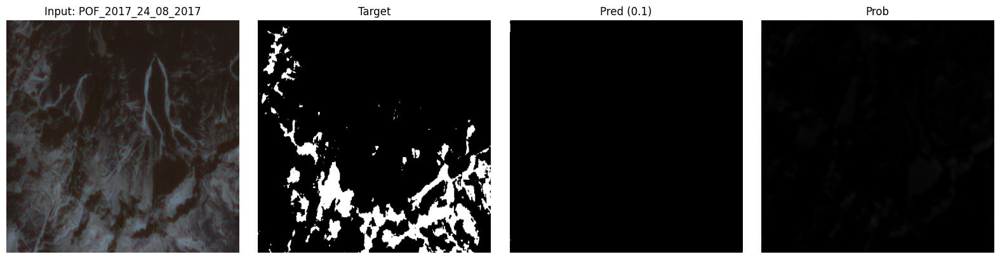

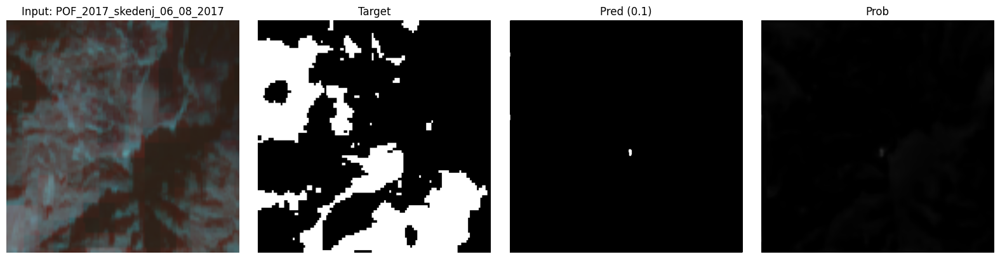

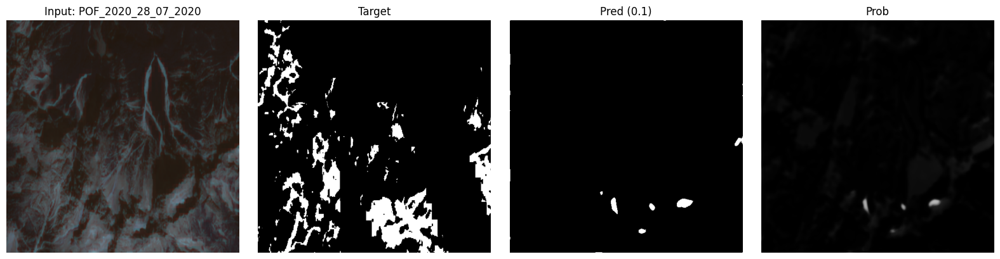

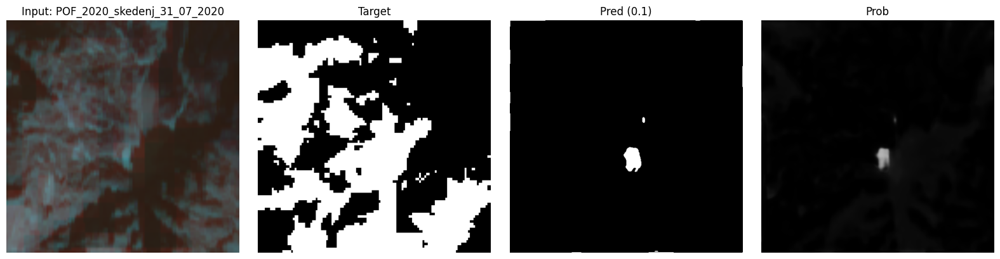

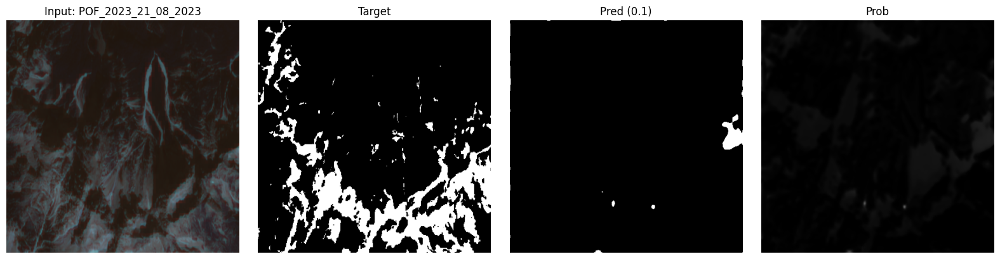

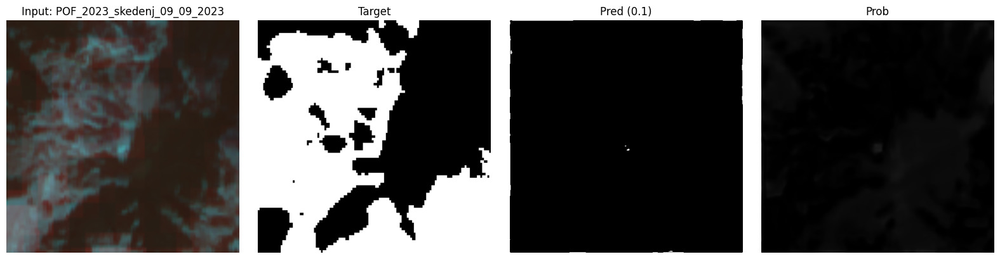

target IoU: class0=0.6106, class1=0.1296, mIoU=0.3701
target F1 : class0=0.7582, class1=0.2294, mF1 =0.4938
handGT IoU: class0=0.7886, class1=0.0411, mIoU=0.4149
handGT F1 : class0=0.8818, class1=0.0790, mF1 =0.4804
Saved predictions to D:\analiza_snezisc2\3_train_state_of_the_art\trained_model\all\Unet\CrossEntropyLoss\predictions
Working on probability: 0.25


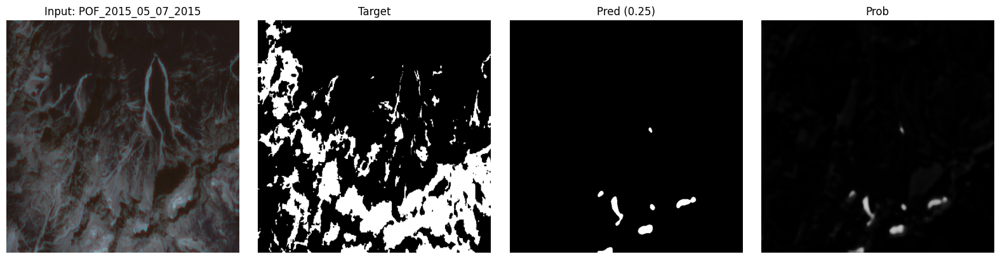

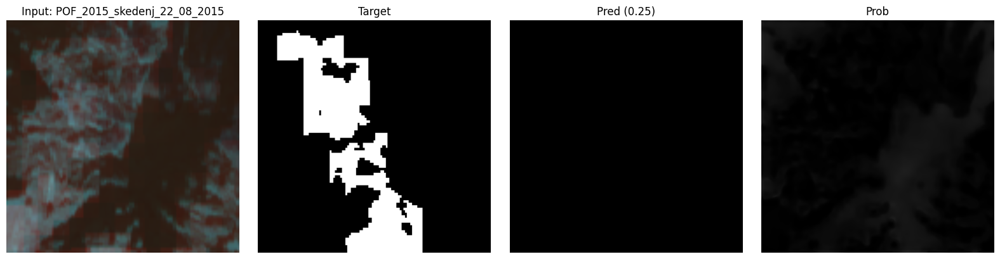

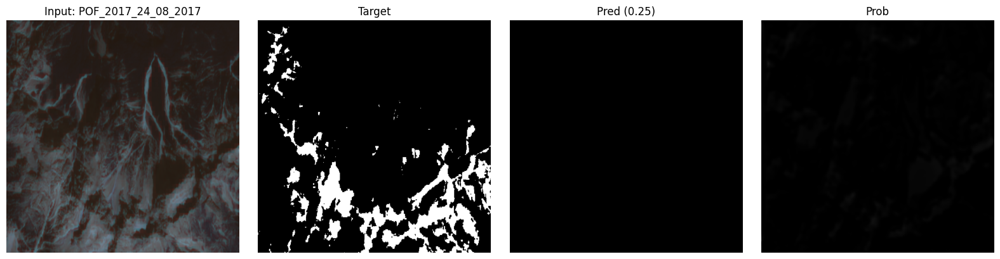

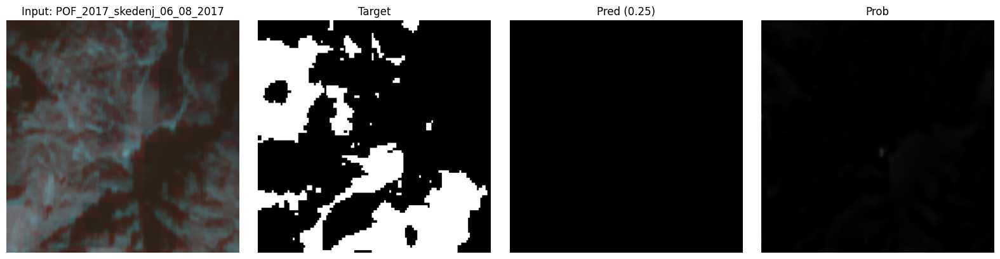

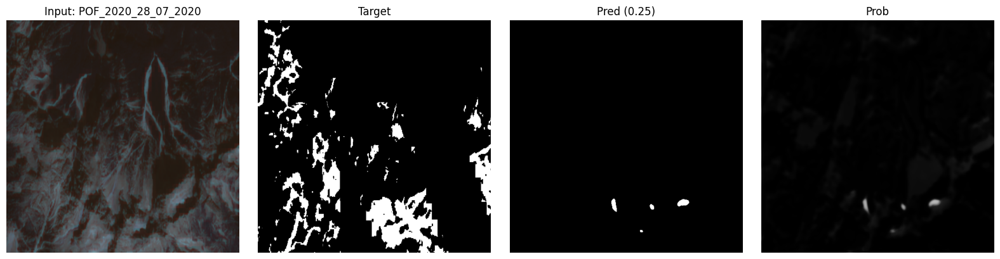

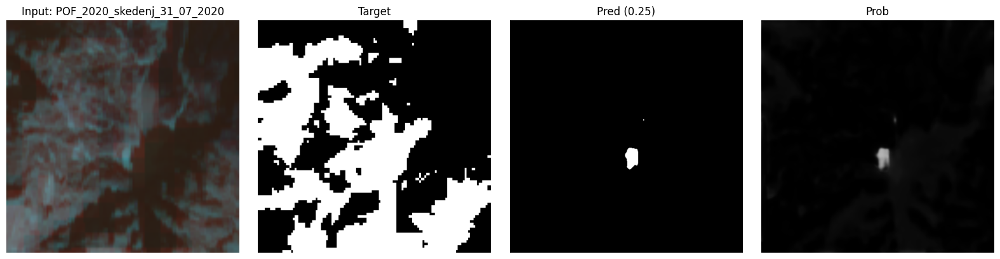

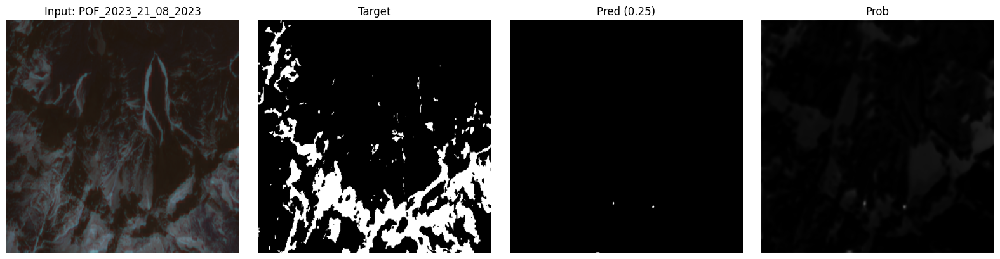

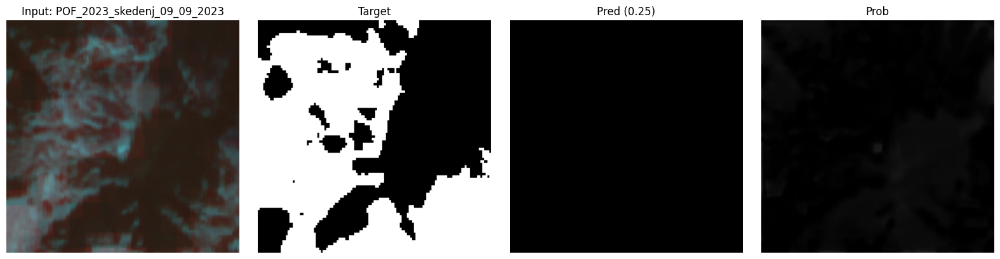

target IoU: class0=0.6531, class1=0.0999, mIoU=0.3765
target F1 : class0=0.7902, class1=0.1816, mF1 =0.4859
handGT IoU: class0=0.8541, class1=0.0428, mIoU=0.4484
handGT F1 : class0=0.9213, class1=0.0820, mF1 =0.5017
Saved predictions to D:\analiza_snezisc2\3_train_state_of_the_art\trained_model\all\Unet\CrossEntropyLoss\predictions
Working on probability: 0.5


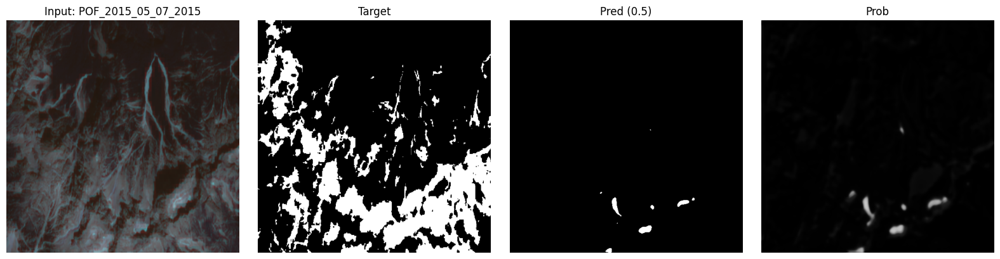

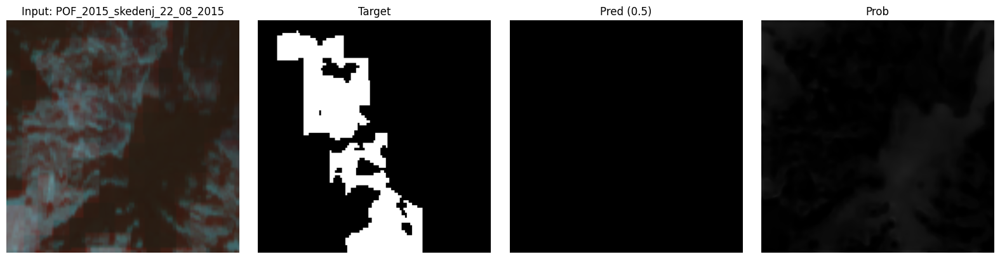

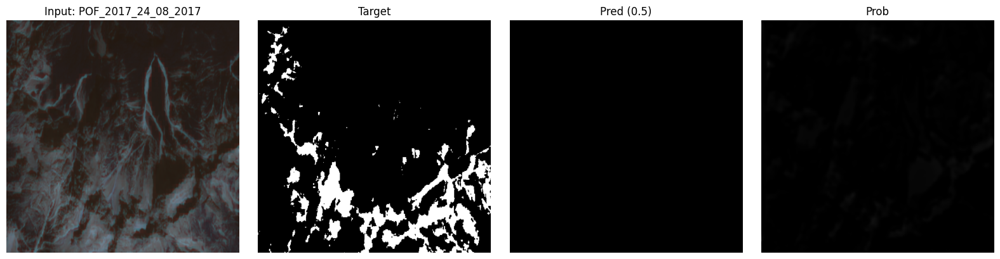

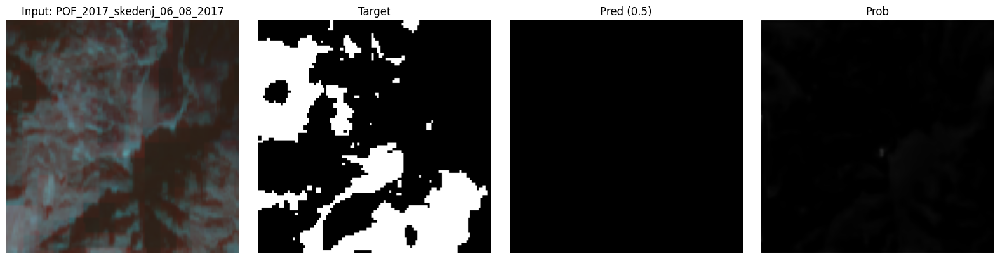

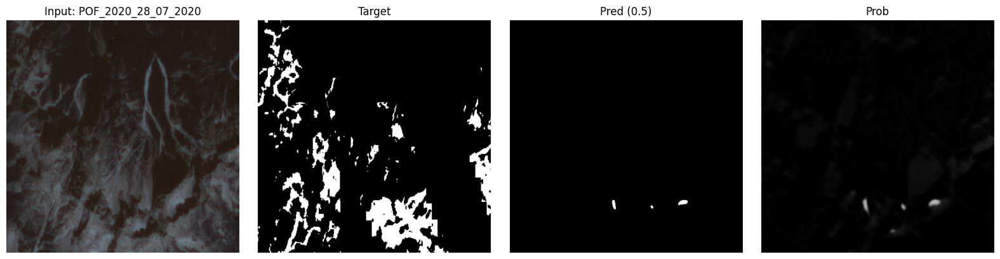

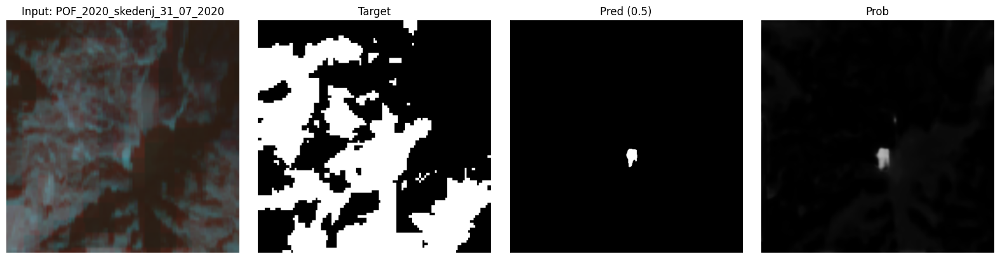

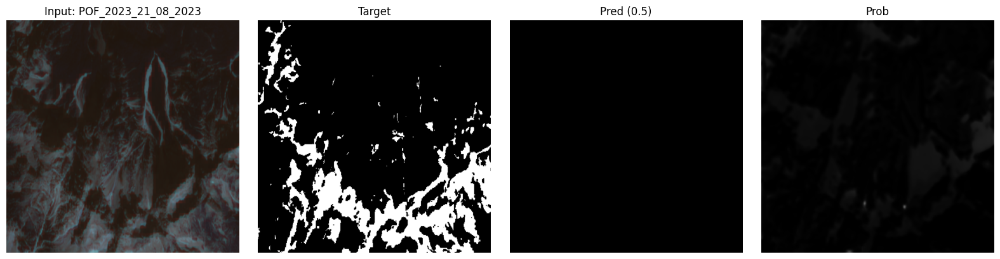

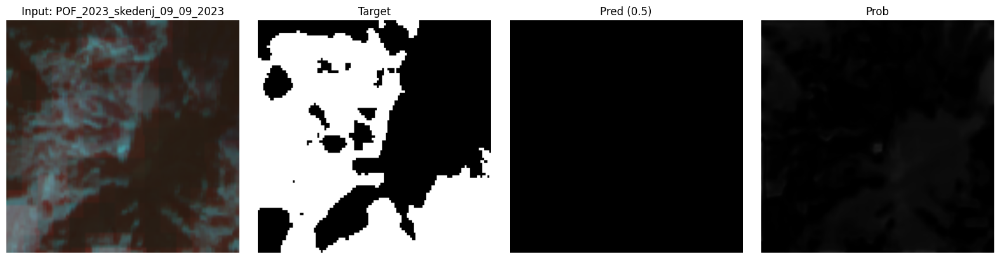

target IoU: class0=0.6737, class1=0.0812, mIoU=0.3774
target F1 : class0=0.8051, class1=0.1501, mF1 =0.4776
handGT IoU: class0=0.8866, class1=0.0431, mIoU=0.4649
handGT F1 : class0=0.9399, class1=0.0826, mF1 =0.5113
Saved predictions to D:\analiza_snezisc2\3_train_state_of_the_art\trained_model\all\Unet\CrossEntropyLoss\predictions


In [9]:
TEST_DATASET_ROOT_CANDIDATES = [
    Path('2_download_test_data_and_create_test_dataset/test_dataset'),
    Path('../2_download_test_data_and_create_test_dataset/test_dataset'),
    Path('../../2_download_test_data_and_create_test_dataset/test_dataset'),
]

def find_test_dataset_root() -> Path:
    for candidate in TEST_DATASET_ROOT_CANDIDATES:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not locate test dataset directory. Update TEST_DATASET_ROOT_CANDIDATES.')

TEST_DATASET_ROOT = find_test_dataset_root()
TEST_MANIFEST_PATH = TEST_DATASET_ROOT / 'manifest.csv'
test_manifest = pd.read_csv(TEST_MANIFEST_PATH)
print(f'Loaded {len(test_manifest)} test tiles from {TEST_MANIFEST_PATH}')

def resolve_test_path(relative_path: str) -> Path:
    normalized = relative_path.replace('\\', '/')
    return TEST_DATASET_ROOT / Path(normalized)

test_dataset = SnowSegmentationDataset(
    test_manifest,
    list(range(len(test_manifest))),
    SELECTED_BANDS,
    CONFIG['image_size'],
    CONFIG['mask_size'],
    augment=False,
    resolve_path_fn=resolve_test_path,
)

pred_dir = TRAINED_MODEL_DIR / 'predictions'
snow_label_dir = TEST_DATASET_ROOT / 'snow_labels'
hand_gt_dir = TEST_DATASET_ROOT / 'given_gt_snow_labels'
label_dir = pred_dir / 'labels'
prob_dir = pred_dir / 'probabilities'
label_dir.mkdir(parents=True, exist_ok=True)
prob_dir.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
model.to(device)

prediction_vs_target_intersection = 0
prediction_vs_target_union = 0
prediction_vs_target_tp = 0
prediction_vs_target_fp = 0
prediction_vs_target_fn = 0
prediction_vs_hand_gt_intersection = 0
prediction_vs_hand_gt_union = 0
prediction_vs_hand_gt_tp = 0
prediction_vs_hand_gt_fp = 0
prediction_vs_hand_gt_fn = 0

# ---- add these accumulators near your other totals ----
# target
t_tp0 = t_fp0 = t_fn0 = 0
t_tp1 = t_fp1 = t_fn1 = 0

# hand-gt
h_tp0 = h_fp0 = h_fn0 = 0
h_tp1 = h_fp1 = h_fn1 = 0


def accumulate_binary_confusions(pred_bin: np.ndarray, gt_bin: np.ndarray):
    """
    pred_bin, gt_bin are {0,1} uint8 arrays with same shape.
    Returns:
      (tp1, fp1, fn1, tp0, fp0, fn0)
    """
    pred1 = (pred_bin == 1)
    gt1   = (gt_bin == 1)
    pred0 = ~pred1
    gt0   = ~gt1

    tp1 = int((pred1 & gt1).sum())
    fp1 = int((pred1 & gt0).sum())
    fn1 = int((pred0 & gt1).sum())

    tp0 = int((pred0 & gt0).sum())
    fp0 = int((pred0 & gt1).sum())
    fn0 = int((pred1 & gt0).sum())

    return tp1, fp1, fn1, tp0, fp0, fn0


def iou_from_counts(tp, fp, fn):
    den = tp + fp + fn
    return (tp / den) if den > 0 else float("nan")

def f1_from_counts(tp, fp, fn):
    den = 2 * tp + fp + fn
    return (2 * tp / den) if den > 0 else float("nan")

for prob in [0.01, 0.1, 0.25, 0.5]:
    print("Working on probability:", prob)
    for idx in range(len(test_dataset)):
        entry = test_manifest.iloc[idx]
        image_tensor, target_tensor = test_dataset[idx]
        image_np = image_tensor.cpu().numpy()
        input_batch = image_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(input_batch)
            probs = torch.softmax(logits, dim=1)[:, 1]
        prob_np = probs.squeeze(0).cpu().numpy()
        label_np = (prob_np >= prob).astype(np.uint8)
        #print("output size:", label_np.shape)
        base_name = Path(entry['sentinel_path']).stem
        target_mask_path = snow_label_dir / f'{base_name}.tif'
        hand_gt_path = hand_gt_dir / f'{base_name}.tif'
        if target_mask_path.exists():
            target_mask = rasterio.open(target_mask_path).read(1).astype(np.uint8)
        else:
            target_mask = None
        if hand_gt_path.exists():
            hand_gt_mask = rasterio.open(hand_gt_path).read(1).astype(np.uint8)
        else:
            hand_gt_mask = None
        label_path = label_dir / f'{base_name}_{prob}.png'
        prob_path = prob_dir / f'{base_name}_{prob}.png'
        show_image = image_np[:3] if image_np.shape[0] >= 3 else image_np
        show_image = show_image.transpose(1, 2, 0)
        target_np = target_tensor.cpu().numpy()
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        axes[0].imshow(show_image)
        axes[0].set_title(f'Input: {base_name}')
        axes[0].axis('off')
        axes[1].imshow(target_np, cmap='gray', vmin=0, vmax=1)
        axes[1].set_title('Target')
        axes[1].axis('off')
        axes[2].imshow(label_np, cmap='gray', vmin=0, vmax=1)
        axes[2].set_title('Pred (' + str(prob) + ')')
        axes[2].axis('off')
        axes[3].imshow(prob_np, cmap='gray', vmin=0, vmax=1)
        axes[3].set_title('Prob')
        axes[3].axis('off')
        plt.tight_layout()
        plt.show()
        plt.imsave(label_path, label_np, cmap='gray', vmin=0, vmax=1)
        plt.imsave(prob_path, prob_np, cmap='gray', vmin=0, vmax=1)
        if target_mask is not None:
            target_mask = cv2.resize(
                target_mask,
                (CONFIG["mask_size"], CONFIG["mask_size"]),
                interpolation=cv2.INTER_NEAREST
            )
        
            target_bin = (target_mask > 0).astype(np.uint8)
            pred_bin   = (label_np > 0).astype(np.uint8)
        
            tp1, fp1, fn1, tp0, fp0, fn0 = accumulate_binary_confusions(pred_bin, target_bin)
        
            # keep your existing "positive class" totals if you still want them:
            prediction_vs_target_tp += tp1
            prediction_vs_target_fp += fp1
            prediction_vs_target_fn += fn1
            prediction_vs_target_intersection += tp1
            prediction_vs_target_union += (tp1 + fp1 + fn1)
        
            # new macro totals (both classes)
            t_tp1 += tp1; t_fp1 += fp1; t_fn1 += fn1
            t_tp0 += tp0; t_fp0 += fp0; t_fn0 += fn0
        if hand_gt_mask is not None:
            hand_gt_mask = cv2.resize(
                hand_gt_mask,
                (CONFIG["mask_size"], CONFIG["mask_size"]),
                interpolation=cv2.INTER_NEAREST
            )
        
            hand_gt_bin = (hand_gt_mask > 0).astype(np.uint8)
            pred_bin    = (label_np > 0).astype(np.uint8)
        
            tp1, fp1, fn1, tp0, fp0, fn0 = accumulate_binary_confusions(pred_bin, hand_gt_bin)
        
            prediction_vs_hand_gt_tp += tp1
            prediction_vs_hand_gt_fp += fp1
            prediction_vs_hand_gt_fn += fn1
            prediction_vs_hand_gt_intersection += tp1
            prediction_vs_hand_gt_union += (tp1 + fp1 + fn1)
        
            h_tp1 += tp1; h_fp1 += fp1; h_fn1 += fn1
            h_tp0 += tp0; h_fp0 += fp0; h_fn0 += fn0
    
    # ---- TARGET metrics ----
    iou1 = iou_from_counts(t_tp1, t_fp1, t_fn1)
    iou0 = iou_from_counts(t_tp0, t_fp0, t_fn0)
    miou = (iou0 + iou1) / 2
    
    f11 = f1_from_counts(t_tp1, t_fp1, t_fn1)
    f10 = f1_from_counts(t_tp0, t_fp0, t_fn0)
    mf1 = (f10 + f11) / 2
    
    print(f"target IoU: class0={iou0:.4f}, class1={iou1:.4f}, mIoU={miou:.4f}")
    print(f"target F1 : class0={f10:.4f}, class1={f11:.4f}, mF1 ={mf1:.4f}")
    
    # ---- HAND-GT metrics ----
    iou1 = iou_from_counts(h_tp1, h_fp1, h_fn1)
    iou0 = iou_from_counts(h_tp0, h_fp0, h_fn0)
    miou = (iou0 + iou1) / 2
    
    f11 = f1_from_counts(h_tp1, h_fp1, h_fn1)
    f10 = f1_from_counts(h_tp0, h_fp0, h_fn0)
    mf1 = (f10 + f11) / 2
    
    print(f"handGT IoU: class0={iou0:.4f}, class1={iou1:.4f}, mIoU={miou:.4f}")
    print(f"handGT F1 : class0={f10:.4f}, class1={f11:.4f}, mF1 ={mf1:.4f}")
    
    print(f'Saved predictions to {pred_dir}')